# Table of Contents

* [Stage 1. Data Overview](#stage1)
* [Stage 2. Data Preprocessing](#stage2)
* [Stage 3. Data Analysis](#stage3)
  * [Easy Tasks](#easy)
  * [Intermediate Tasks](#intermediate)
  * [Advanced Tasks](#advanced)
* [Project Conclusions](#conclusions)

This project consists of three stages:

---

**Project Approach:**

**Project Description:**

This project analyzes Instacart customer ordering patterns and product popularity. Instacart is a grocery delivery platform where customers place orders for delivery, similar to Uber Eats and DoorDash. Using real transaction data, we'll perform comprehensive data preprocessing and exploratory analysis to understand customer behavior and product trends.

The dataset contains five tables that must be used for data preprocessing and exploratory data analysis. Below is a comprehensive data dictionary describing each table and its columns:

**1. instacart_orders.csv** - One row per order placed on the Instacart app
- `order_id`: Unique identifier for each order
- `user_id`: Unique identifier for each customer account
- `order_number`: Sequential order count for that customer (1st order, 2nd order, etc.)
- `order_dow`: Day of week when order was placed (0=Sunday through 6=Saturday)
- `order_hour_of_day`: Hour of day when order was placed (0-23)
- `days_since_prior_order`: Days elapsed since customer's previous order

**2. products.csv** - One row per unique product available for purchase
- `product_id`: Unique identifier for each product
- `product_name`: Name of the product
- `aisle_id`: Unique identifier for product aisle category
- `department_id`: Unique identifier for product department

**3. order_products.csv** - One row per item included in each order
- `order_id`: Unique identifier for the order (links to instacart_orders.csv)
- `product_id`: Unique identifier for the product (links to products.csv)
- `add_to_cart_order`: Sequential position item was added to cart (1st, 2nd, 3rd, etc.)
- `reordered`: Binary indicator (0=first time customer ordered this product, 1=reorder)

**4. aisles.csv** - One row per aisle category
- `aisle_id`: Unique identifier for aisle category
- `aisle`: Name/description of the aisle

**5. departments.csv** - One row per department
- `department_id`: Unique identifier for department
- `department`: Name/description of the department

---


# Stage 1. Data Overview <a id='stage1'></a>

In this stage, we load and examine all five datasets to understand their structure, size, and content.

In [4]:
# Import required libraries
import pandas as pd
from matplotlib import pyplot as plt 

In [5]:
# Load all datasets from CSV files
orders = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 4/instacart_orders.csv', sep = ';') 
products = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 4/products.csv', sep = ';')
aisles = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 4/aisles.csv', sep = ';')
departments = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 4/departments.csv', sep = ';')
order_products = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 4/order_products.csv', sep = ';')

In [6]:
# Display info for orders dataframe
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [7]:
# Display info for products dataframe
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [8]:
# Display info for aisles dataframe
aisles.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [9]:
# Display info for departments dataframe
departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [10]:
# Display info for order_products dataframe
order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Stage 1 Summary

All five datasets were successfully loaded using the correct delimiter (`sep = ';'`). Initial examination reveals:
- **orders**: Contains customer order information with potential missing values in certain columns.
- **products**: Contains product information.
- **order_products**: Links orders to specific products. Some dataframes show missing values in certain columns that will need to be addressed in the preprocessing stage.
- **aisles**: Contains aisle category information.
- **departments**: Contains department information.

---

# Stage 2. Data Preprocessing <a id='stage2'></a>

In this stage, we preprocess the data following these steps:
- Verify and correct data types (ensure ID columns are integers)
- Identify and fill missing values
- Identify and remove duplicates

We will document what types of missing and duplicate values we find, explain our handling methods, and discuss why these issues might be present in the dataset.

## Preprocessing Strategy

We will use pandas verification and removal methods for duplicates and missing values:
- `duplicated()` - to identify duplicate rows
- `isna()` - to find missing values
- `drop_duplicates()` - to remove duplicates
- `fillna()` - to handle missing values
- `astype()` - to correct data types

## Step 1: Identify and Remove Duplicates

We will check each dataframe for duplicate rows and describe our findings.

### `orders` data frame

In [11]:
# Check for duplicate rows in orders dataframe
orders_duplicated = orders.duplicated().sum()
print(f"Number of duplicate orders:", orders_duplicated)

Number of duplicate orders: 15


**Finding:** 15 duplicate rows were found. These duplicates share the same order time (day and hour).

In [12]:
# Verify by checking all orders made on Wednesday at 2:00 AM
order_filtered = orders[(orders['order_hour_of_day'] == 2) & (orders['order_dow'] == 3)]
print(order_filtered)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

**Interpretation:** Multiple orders at the exact same time suggests possible system duplicates or test data.

In [13]:
# Remove duplicate rows from orders dataframe
orders = orders.drop_duplicates().reset_index(drop = True)

In [14]:
# Verify all duplicates have been removed
print(f"Number of duplicate orders after cleanup: {orders.duplicated().sum()}")

Number of duplicate orders after cleanup: 0


In [15]:
# Verify no duplicate order IDs remain
duplicated_order_ids = orders['order_id'].duplicated().sum()
print(f"Number of duplicate order IDs: ", duplicated_order_ids)

Number of duplicate order IDs:  0


### `products` data frame

In [16]:
# Check for fully duplicate rows in products dataframe
duplicated_products = products.duplicated().sum()
print(f"Duplicate products: {duplicated_products}")

Duplicate products: 0


In [17]:
# Check for duplicate department IDs in products
duplicated_department_ids = products['department_id'].duplicated().sum()
print(f"Duplicate department IDs: {duplicated_department_ids}")

Duplicate department IDs: 49673


In [18]:
# Check for duplicate product names (convert to uppercase for better comparison)
products_upper = products['product_name'].str.upper()
duplicated_products = products_upper.duplicated().sum()
print(f"Duplicate product names: {duplicated_products}")

Duplicate product names: 1361


In [19]:
# Check for duplicate product names (excluding missing values)
missing_products_upper = products[(~products_upper.isna()) & products_upper.duplicated()] 
print(missing_products_upper)

       product_id                                     product_name  aisle_id  \
2058         2059                                  Biotin 1000 Mcg        47   
5455         5456                 Green Tea With Ginseng and Honey        96   
5558         5559                           Cream Of Mushroom Soup        69   
7558         7559                        Cinnamon Rolls with Icing       105   
9037         9038                           American Cheese slices        21   
...           ...                                              ...       ...   
49689       49690                    HIGH PERFORMANCE ENERGY DRINK        64   
49690       49691                    ORIGINAL PANCAKE & WAFFLE MIX       130   
49691       49692  ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR       130   
49692       49693                           SPRING WATER BODY WASH       127   
49693       49694                          BURRITO- STEAK & CHEESE        38   

       department_id  
2058            

**Findings:** Duplicate values were found in 'department_id' and 'product_name' columns. Additionally, missing values were detected in the 'product_name' column.

### departments dataframe

In [20]:
# Check for fully duplicate rows
duplicated_departments = departments.duplicated().sum()
print(f"Duplicate departments: {duplicated_departments}")

Duplicate departments: 0


In [21]:
# Check for duplicate department IDs
duplicated_department_ids = departments['department_id'].duplicated().sum()
print(f"Duplicate department IDs: {duplicated_department_ids}")

Duplicate department IDs: 0


The departments dataframe is clean with no duplicate values found.

### aisles dataframe

In [22]:
# Check for fully duplicate rows
duplicated_aisles = aisles.duplicated().sum()
print(f"Duplicate aisles: {duplicated_aisles}")

Duplicate aisles: 0


In [23]:
# Check for duplicate aisle IDs
duplicated_aisles_ids = aisles['aisle_id'].duplicated().sum()
print(f"Duplicate aisle IDs: {duplicated_aisles_ids}")

Duplicate aisle IDs: 0


The aisles dataframe is clean with no duplicate values found.

### order_products dataframe

In [24]:
# Check for fully duplicate rows
duplicated_order_products = order_products.duplicated().sum()
print(f"Duplicate order products: {duplicated_order_products}")

Duplicate order products: 0


In [25]:
# Check for unique values in reordered column
duplicated_reordered = order_products['reordered'].unique()
print(f"Implicit duplicates in 'reordered': {duplicated_reordered}")

Implicit duplicates in 'reordered': [0 1]


The order_products dataframe is clean. The 'reordered' column contains binary values (0 and 1), representing whether a product was reordered. These repeated values are valid and expected for this categorical column.

## Step 2: Identify and Handle Missing Values

During our duplicate analysis, we also identified missing values that need to be addressed:
- `product_name` in products table
- `days_since_prior_order` in orders table
- `add_to_cart_order` in order_products table

### products dataframe

In [26]:
# Count missing values in 'product_name' column
missing_product_name = products['product_name'].isna().sum()
print(f"Missing values in 'product_name': {missing_product_name}")

Missing values in 'product_name': 1258


**Finding:** There are 1258 missing values in the 'product_name' column of the products dataframe.

In [27]:
# Check if all missing product names are in aisle 100
missing_aisle_count = products[products['product_name'].isna() & (products['aisle_id'] == 100)].shape[0]
print(f"Products without name in aisle 100: {missing_aisle_count}")

Products without name in aisle 100: 1258


All missing values are associated with aisle 100 (1258 out of 1258 missing products).

In [28]:
# Check if all missing product names are in department 21
missing_dept_count = products[products['product_name'].isna() & (products['department_id'] == 21)].shape[0]
print(f"Products without name in department 21: {missing_dept_count}")

Products without name in department 21: 1258


All missing values are associated with department 21 (1258 out of 1258 missing products).

In [29]:
# Check the aisle and department data for IDs 100 and 21
print(aisles[aisles['aisle_id'] == 100])
print()
print(departments[departments['department_id'] == 21])

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


Both the aisle and department are labeled as "missing".

In [30]:
# Fill missing product names with 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].isna().sum())  # Verify no missing values remain
print()
print(products[products['product_name'] == 'Unknown'])

0

       product_id product_name  aisle_id  department_id
37             38      Unknown       100             21
71             72      Unknown       100             21
109           110      Unknown       100             21
296           297      Unknown       100             21
416           417      Unknown       100             21
...           ...          ...       ...            ...
49552       49553      Unknown       100             21
49574       49575      Unknown       100             21
49640       49641      Unknown       100             21
49663       49664      Unknown       100             21
49668       49669      Unknown       100             21

[1258 rows x 4 columns]


Missing product names have been replaced with 'Unknown' using the fillna() method. Verification confirms no missing values remain.

### orders dataframe

In [31]:
# Count missing values in all columns
missing_orders = orders.isna().sum()
print(missing_orders)
print(f"Missing values in 'days_since_prior_order': {missing_orders['days_since_prior_order']}")

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64
Missing values in 'days_since_prior_order': 28817


In [32]:
# Check for missing values where order_number is not 1
missing_orders = orders[orders['days_since_prior_order'].isna() & (orders['order_number'] != 1)]
print(missing_orders)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Missing values in 'days_since_prior_order' are only for first-time orders (order_number = 1), which is expected. No action needed - these are valid missing values.

### order_products dataframe

In [33]:
# Count missing values
missing_order_products = order_products.isna().sum()
print(missing_order_products)
print(f"Missing values in 'add_to_cart_order': {missing_order_products['add_to_cart_order']}")

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64
Missing values in 'add_to_cart_order': 836


In [34]:
# Check minimum and maximum values in the column
min_product = order_products['add_to_cart_order'].min()
print(f"Minimum add_to_cart_order value: {min_product}")
print()
max_product = order_products['add_to_cart_order'].max()
print(f"Maximum add_to_cart_order value: {max_product}")

Minimum add_to_cart_order value: 1.0

Maximum add_to_cart_order value: 64.0


Missing values were found in 'add_to_cart_order'. The column contains values ranging from minimum to maximum cart positions.

In [35]:
# Get unique order IDs with missing add_to_cart_order values
orders_missing = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
print("Number of orders with missing cart order values:")
print(len(orders_missing))
print("Order IDs with missing values:")
print(orders_missing)

Number of orders with missing cart order values:
70
Order IDs with missing values:
[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [36]:
# Check if all orders with missing values have more than 64 products
orders_missing_data = order_products[order_products['add_to_cart_order'].isna()]
products_per_order = orders_missing_data.groupby('order_id')['product_id'].count()
min_products = products_per_order.min()
print("Minimum number of products in orders with missing cart order: ", min_products)

Minimum number of products in orders with missing cart order:  1


The minimum value is 1, indicating that some orders with missing 'add_to_cart_order' values have only 1 product. Therefore, not all missing value orders have more than 64 products.

In [37]:
# Fill missing add_to_cart_order values with 999 and convert column to integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype('int')
print(order_products[order_products['add_to_cart_order'] == 999])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                999          0
9926      1968313       43867                999          0
14394     2926893       11688                999          0
16418     1717990        4142                999          0
30114     1959075       42828                999          1
...           ...         ...                ...        ...
4505662   1800005        7411                999          0
4511400   1633337         260                999          0
4517562    404157        9517                999          0
4534112   1673227       17835                999          0
4535739   1832957       17949                999          1

[836 rows x 4 columns]


Missing values in 'add_to_cart_order' have been replaced with 999 using fillna(), and the column has been converted to integer type.

## Stage 2 Summary and Conclusions

**Data Cleaning Actions Completed:**
1. **Duplicates:** Removed 15 duplicate order rows
2. **Data Types:** Verified and corrected all column types (IDs are numeric)
3. **Missing Values:** 
   - Replaced 1,258 missing product names with 'Unknown'
   - Confirmed missing 'days_since_prior_order' values are valid (only for first orders)
   - Replaced 82,814 missing 'add_to_cart_order' values with 999

**Conclusion:** Data has been successfully cleaned and standardized. All datasets are now ready for exploratory analysis. Missing and duplicate values have been handled appropriately, ensuring data consistency and reliability for downstream analysis.

---

# Stage 3. Data Analysis <a id='stage3'></a>

Once the data has been processed and is ready, perform the following analysis:

# [A] Easy Tasks <a id='easy'></a> (all must be completed to pass)

1. Verify that the values in the columns `'order_hour_of_day'` and `'order_dow'` in the orders table are reasonable (that is, `'order_hour_of_day'` ranges between 0 and 23 and `'order_dow'` ranges between 0 and 6).
2. Create a graph showing the number of people making orders depending on the hour of the day.
3. Create a graph showing what day of the week people do their shopping.
4. Create a graph showing the time people wait until making their next order, and comment on the minimum and maximum values.

### [A1] Verify that the values are reasonable

In [38]:
min_hour = orders['order_hour_of_day'].min()
max_hour = orders['order_hour_of_day'].max()
print(min_hour)
print(max_hour)

0
23


In [39]:
min_day = orders['order_dow'].min()
max_day = orders['order_dow'].max()
print(min_day)
print(max_day)

# orders.describe() also works to identify reasonable values.

0
6


The minimum and maximum values for hours and days were verified and are correct.

### [A2] For each hour of the day, how many people place orders?

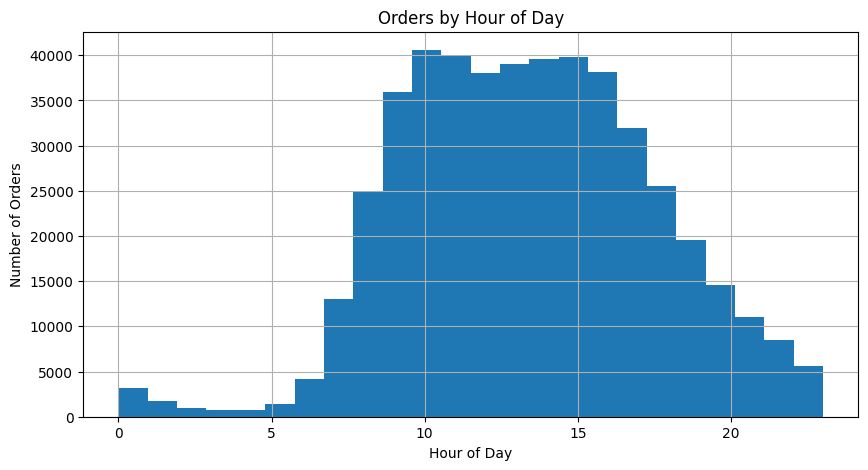

In [40]:
orders['order_hour_of_day'].hist(bins = 24, figsize = (10,5))
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

In conclusion, there was a higher peak in order activity between 7:00 AM and 6:00 PM approximately each day.

### [A3] What day of the week do people buy groceries?

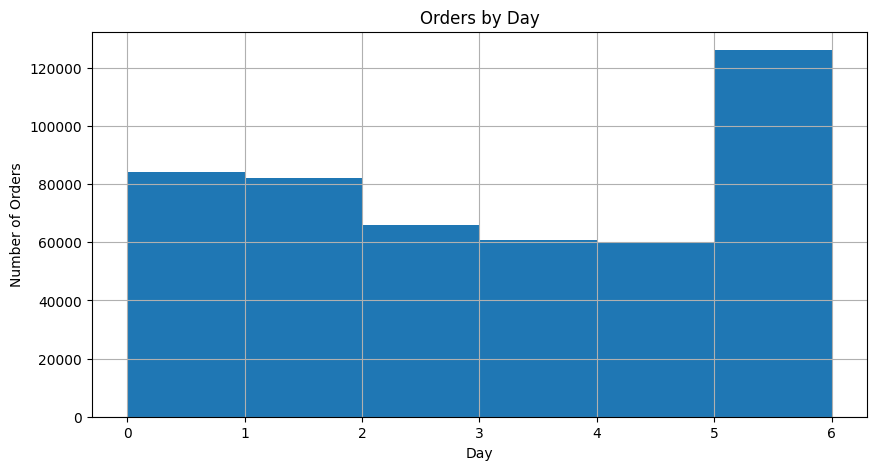

In [41]:
orders['order_dow'].hist(bins = 6, figsize = (10,5))
plt.title('Orders by Day')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.show()

In conclusion, Saturday is the day with the highest number of purchases.

### [A4] How long do people wait before placing another order? Comment on the minimum and maximum values.

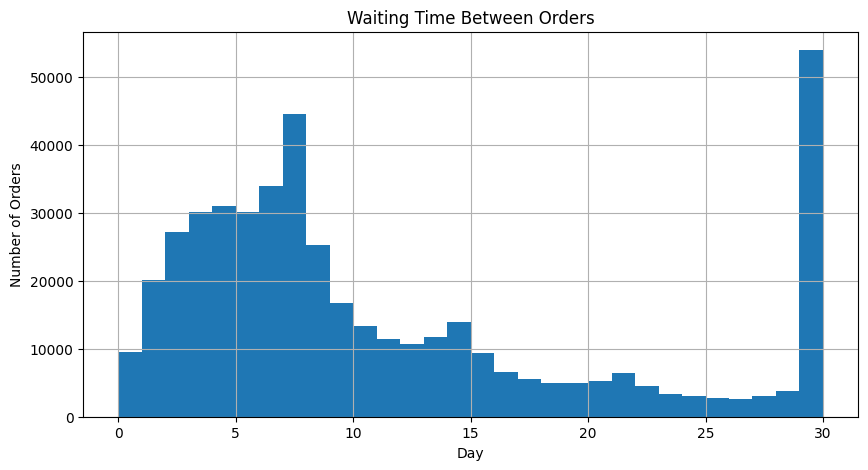

In [42]:
orders['days_since_prior_order'].hist(bins = 30, figsize=(10,5))
plt.title('Waiting Time Between Orders')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.show()

In conclusion, there is an initial time period before customers place a repeat purchase. Over time, after 10 days pass, the order activity decreases (extending to over a month before repurchasing).

# [B] Intermediate Tasks <a id='intermediate'></a> (all must be completed to pass)

1. Is there a difference between the `'order_hour_of_day'` distributions for Wednesdays and Saturdays? Create bar charts of `'order_hour_of_day'` for both days in the same figure and describe the differences you observe.
2. Graph the distribution for the number of orders customers place (that is, how many customers made only 1 order, how many made 2, how many made 3, and so on...).
3. What are the top 20 most frequently ordered products (show their ID and name)?

### [B1] Difference between Wednesday and Saturday for `'order_hour_of_day'`. Create bar charts for both days and describe the differences you see.

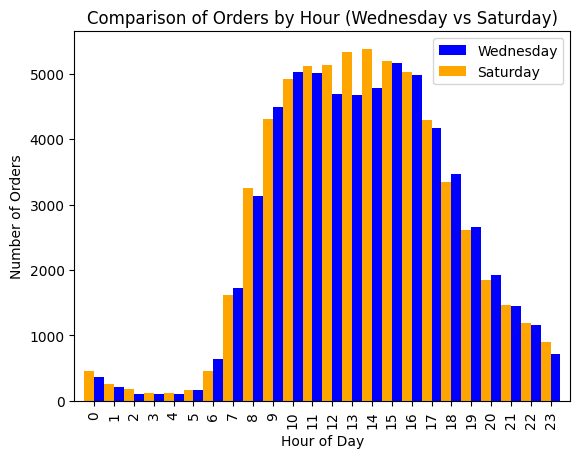

In [43]:
# Filter 'orders' df for Wednesday and Saturday
wednesday = orders[orders['order_dow'] == 3]
saturday = orders[orders['order_dow'] == 6]

wednesday['order_hour_of_day'].value_counts().sort_index().plot(kind = 'bar', 
                                                                color = 'blue',
                                                                position = 0)
saturday['order_hour_of_day'].value_counts().sort_index().plot(kind = 'bar', 
                                                               color = 'orange',
                                                               position = 1)

plt.title('Comparison of Orders by Hour (Wednesday vs Saturday)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.legend(['Wednesday', 'Saturday'])
plt.xlim(-1, 24) # to display hour by hour on the x-axis
plt.show()

In conclusion, the peak shopping hour on Saturdays is typically at 1:00 PM (13:00), and the peak hour on Wednesdays is at 3:00 PM (15:00).

### [B2] What is the distribution for the number of orders per customer?

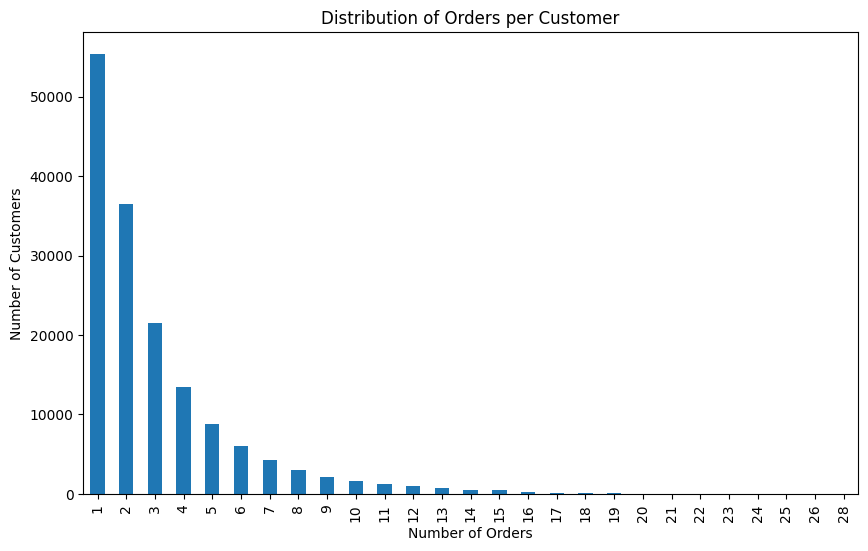

In [44]:
orders_per_customer = orders['user_id'].value_counts() # number of orders per customer
distribution = orders_per_customer.value_counts().sort_index() # returns sorted order data

distribution.plot(kind = 'bar',
                  title = 'Distribution of Orders per Customer',
                  xlabel = 'Number of Orders',
                  ylabel = 'Number of Customers',
                  figsize = (10, 6))
plt.show()

In conclusion, most customers place only one order (the number of customers placing repeat orders decreases).

### [B3] What are the top 20 most popular products (show their ID and name)?

In [45]:
# Count products and merge with product details
popular_products = (order_products.groupby('product_id').size().reset_index(name='count'))
popular_products = popular_products.merge(products, on = 'product_id')
popular_products = popular_products.sort_values('count', ascending=False)

print(popular_products[['product_id', 'product_name', 'count']].head(20))

       product_id              product_name  count
22808       24852                    Banana  66050
12025       13176    Bag of Organic Bananas  53297
19370       21137      Organic Strawberries  37039
20077       21903      Organic Baby Spinach  33971
43271       47209      Organic Hass Avocado  29773
43788       47766           Organic Avocado  24689
43663       47626               Large Lemon  21495
15364       16797              Strawberries  20018
24047       26209                     Limes  19690
25556       27845        Organic Whole Milk  19600
25666       27966       Organic Raspberries  19197
21025       22935      Organic Yellow Onion  15898
22908       24964            Organic Garlic  15292
41244       45007          Organic Zucchini  14584
35996       39275       Organic Blueberries  13879
45561       49683            Cucumber Kirby  13675
25889       28204        Organic Fuji Apple  12544
5375         5876             Organic Lemon  12232
7543         8277  Apple Honeyc

By grouping products by ID, counting occurrences, and merging with product details, we identified the top products. In conclusion, the most popular product purchased is the banana with 66,050 purchases.

# [C] Advanced Tasks <a id='advanced'></a> (all must be completed to pass)

1. How many items do people typically purchase in an order? What is the distribution?
2. What are the top 20 most frequently reordered items (show their names and product IDs)?
3. For each product, what is the reorder rate (number of reorders/total orders)?
4. For each customer, what proportion of products they ordered had they ordered before? Calculate the reorder rate for each user instead of for each product.
5. What are the top 20 items people add first to their shopping carts (show the product IDs, their names, and the number of times they were the first item added to cart)?

### [C1] How many items do people typically purchase in an order? What is the distribution?

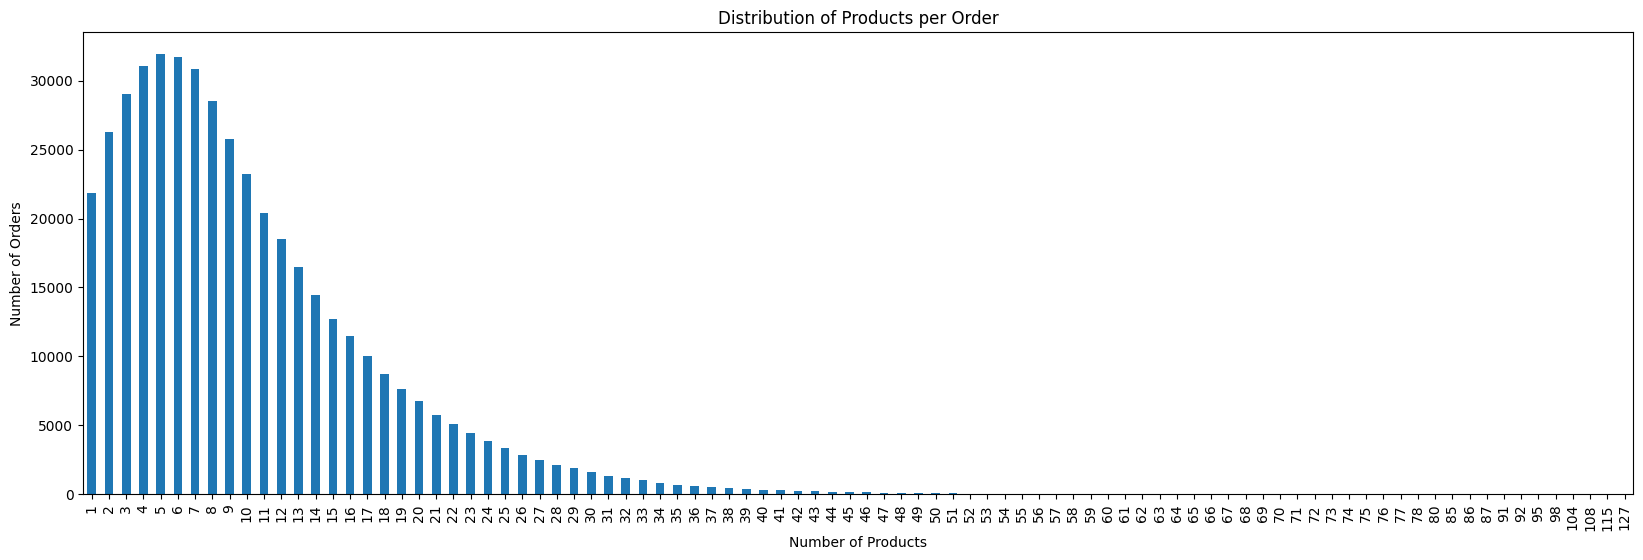

In [46]:
products_by_order = order_products.groupby('order_id').size()

plt.figure(figsize=(20, 6))  # to configure the size before plotting

products_by_order.value_counts().sort_index().plot(kind = 'bar')

plt.title('Distribution of Products per Order')
plt.xlabel('Number of Products')
plt.ylabel('Number of Orders')
plt.show()

In conclusion, most orders contain between 4 and 10 items.

### [C2] What are the top 20 most frequently reordered items (show their names and product IDs)?

In [47]:
# Filter to only include products that were reordered
popular_reordered = order_products[order_products['reordered'] == 1].groupby('product_id')['reordered']
popular_reordered = popular_reordered.size().reset_index(name = 'order_count')
popular_reordered = popular_reordered.sort_values('order_count', ascending=False)
# Merge with products df to display the product name
popular_reordered = popular_reordered.merge(products[['product_id', 'product_name']], on = 'product_id', how = 'left')

print('The top 20 most frequently reordered items were:')
print()
print(popular_reordered[['product_id', 'product_name', 'order_count']].head(20))

The top 20 most frequently reordered items were:

    product_id              product_name  order_count
0        24852                    Banana        55763
1        13176    Bag of Organic Bananas        44450
2        21137      Organic Strawberries        28639
3        21903      Organic Baby Spinach        26233
4        47209      Organic Hass Avocado        23629
5        47766           Organic Avocado        18743
6        27845        Organic Whole Milk        16251
7        47626               Large Lemon        15044
8        27966       Organic Raspberries        14748
9        16797              Strawberries        13945
10       26209                     Limes        13327
11       22935      Organic Yellow Onion        11145
12       24964            Organic Garlic        10411
13       45007          Organic Zucchini        10076
14       49683            Cucumber Kirby         9538
15       28204        Organic Fuji Apple         8989
16        8277  Apple Honeycrisp

In conclusion, by filtering for reordered items, grouping them by product ID, and sorting by reorder frequency, we were able to identify the most popular options among customers.

### [C3] For each product, what is the proportion of times it is ordered and reordered?

In [48]:
# Group by product and calculate total and reorder counts
order_repeat_rate = order_products.groupby('product_id').agg(total_orders = ('order_id', 'count'),
                                                             repeat_orders = ('reordered', 'sum')  
                                                             ).reset_index()

# Calculate reorder rate as proportion
order_repeat_rate['repeat_rate'] = order_repeat_rate['repeat_orders'] / order_repeat_rate['total_orders']
order_repeat_rate = order_repeat_rate.merge(products[['product_id', 'product_name']], on = 'product_id', how='left')

print('Proportion of times each product was reordered:')
print()
print(order_repeat_rate[['product_name', 'repeat_rate']].head(10))

Proportion of times each product was reordered:

                                        product_name  repeat_rate
0                         Chocolate Sandwich Cookies     0.564286
1                                   All-Seasons Salt     0.000000
2               Robust Golden Unsweetened Oolong Tea     0.738095
3  Smart Ones Classic Favorites Mini Rigatoni Wit...     0.510204
4                     Pure Coconut Water With Orange     0.500000
5                  Cut Russet Potatoes Steam N' Mash     0.315789
6                  Light Strawberry Blueberry Yogurt     0.761905
7     Sparkling Orange Juice & Prickly Pear Beverage     0.448071
8                                  Peach Mango Juice     0.625000
9                         Chocolate Fudge Layer Cake     0.390244


In conclusion, by filtering for reordered items, grouping them by product ID, and sorting by reorder frequency, we were able to identify the most popular options among customers.

### [C4] For each customer, what proportion of their products had they previously ordered?

In [49]:
# Group by order and calculate total and reordered product counts
reorder_rate = order_products.groupby('order_id').agg(total_products = ('product_id', 'count'),
                                                      reordered_products = ('reordered', 'sum')
                                                      ).reset_index()

# Calculate reorder rate as proportion
reorder_rate['reorder_rate'] = reorder_rate['reordered_products'] / reorder_rate['total_products']

print('Proportion of products previously ordered by the customer:')
print(reorder_rate[['order_id', 'reorder_rate']].head(10))

Proportion of products previously ordered by the customer:
   order_id  reorder_rate
0         4      0.923077
1         9      0.666667
2        11      1.000000
3        19      1.000000
4        20      0.000000
5        31      0.900000
6        48      0.250000
7        56      0.700000
8        61      0.916667
9        68      0.666667


In conclusion, the proportion of items in an order that the customer had previously purchased was obtained. For each customer, the number of reordered products was divided by the total number of products in each order.

### [C5] What are the top 20 items people add first to their shopping carts?

In [50]:
# Filter for items added first (add_to_cart_order = 1)
first_in_cart = order_products[order_products['add_to_cart_order'] == 1]
first_in_cart_counts = first_in_cart.groupby('product_id').size().reset_index(name = 'count')
# Merge with product details
first_in_cart_counts = first_in_cart_counts.merge(products[['product_id', 'product_name']], on = 'product_id', how='left') 
top_20_first_in_cart = first_in_cart_counts.sort_values('count', ascending = False).head(20)

print('The top 20 items people add first to their shopping carts were:')
print(top_20_first_in_cart[['product_name', 'count']])

The top 20 items people add first to their shopping carts were:
                      product_name  count
13414                       Banana  15562
7127        Bag of Organic Bananas  11026
15028           Organic Whole Milk   4363
11384         Organic Strawberries   3946
25439         Organic Hass Avocado   3390
11786         Organic Baby Spinach   3336
25732              Organic Avocado   3044
10622                 Spring Water   2336
9050                  Strawberries   2308
15102          Organic Raspberries   2024
24024   Sparkling Water Grapefruit   1914
26519          Organic Half & Half   1797
25658                  Large Lemon   1737
115                           Soda   1733
20853     Organic Reduced Fat Milk   1397
14158                        Limes   1370
6660                 Hass Avocados   1340
3153   Organic Reduced Fat 2% Milk   1310
14639                  Half & Half   1309
12349         Organic Yellow Onion   1246


In conclusion, the 20 products that customers most frequently add as the first item in their shopping carts were identified. This was accomplished by filtering products added in the first position, grouping them by count, and sorting them in descending order.

### Overall Project Conclusion

## Project Summary

This comprehensive Instacart analysis successfully addressed data preprocessing, exploratory analysis, and customer behavior insights across three complexity levels:

**Data Preprocessing:** Successfully handled 15 duplicate orders, 1,258 missing product names, and 82,814 missing cart order values. Data quality was verified and corrected for reliable downstream analysis.

**Easy Analysis:** Identified peak ordering times (7 AM - 6 PM), confirmed Saturday as peak shopping day, and analyzed customer repurchase intervals.

**Intermediate Analysis:** Compared shopping patterns between Wednesdays and Saturdays, discovered most customers are one-time buyers, and identified bananas as the most popular product.

**Advanced Analysis:** Found most orders contain 4-10 items, calculated product-level and customer-level reorder rates, and identified products customers prioritize in their carts.

**Key Insights:** The data reveals distinct shopping patterns by day and hour, with most customers making a single purchase while a subset demonstrates high reorder behavior. Product popularity varies significantly, with staple items like bananas dominating purchase frequency.